In [10]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
kandij_diabetes_dataset_path = kagglehub.dataset_download('kandij/diabetes-dataset')

print('Data source import complete.')


Data source import complete.


# What is Diabetes?

Diabetes is a chronic disease that occurs when the pancreas is no longer able to make insulin, or when the body cannot make good use of the insulin it produces.

Insulin is a hormone made by the pancreas, that acts like a key to let glucose from the food we eat pass from the blood stream into the cells in the body to produce energy. All carbohydrate foods are broken down into glucose in the blood. Insulin helps glucose get into the cells.

Not being able to produce insulin or use it effectively leads to raised glucose levels in the blood (known as hyperglycaemia). Over the long-term high glucose levels are associated with damage to the body and failure of various organs and tissues.

# Understanding Data

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import kagglehub
kandij_diabetes_dataset_path = kagglehub.dataset_download('kandij/diabetes-dataset')
print(kandij_diabetes_dataset_path) # for reference



/kaggle/input/diabetes-dataset


In [12]:


# Use the actual downloaded path
data = pd.read_csv(kandij_diabetes_dataset_path + "/diabetes2.csv")


In [13]:
data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [14]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [15]:
data.shape

(768, 9)

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [17]:
data.corr().Outcome.sort_values()

,Outcome
BloodPressure,0.065068
SkinThickness,0.074752
Insulin,0.130548
DiabetesPedigreeFunction,0.173844
Pregnancies,0.221898
Age,0.238356
BMI,0.292695
Glucose,0.466581
Outcome,1.000000


In [18]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


# Visualization

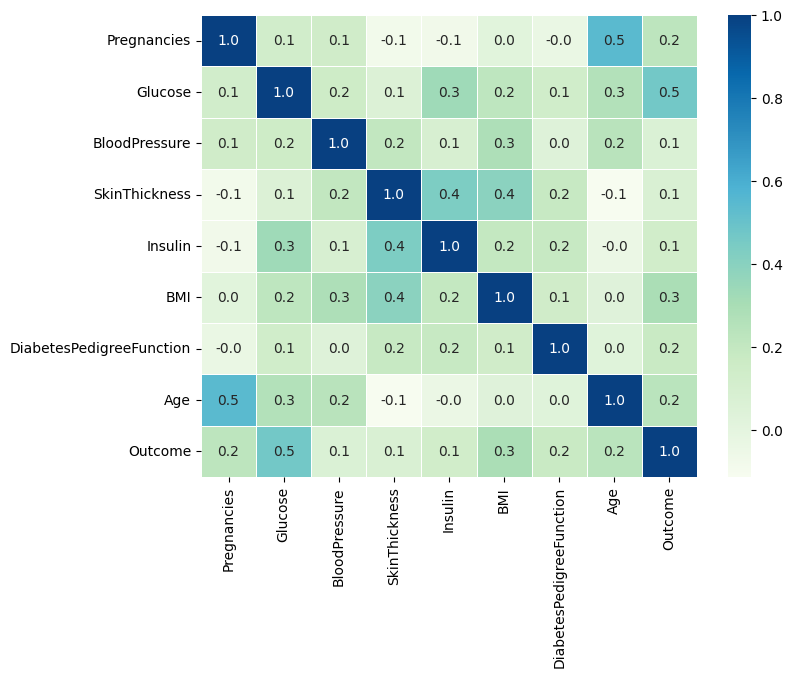

In [19]:
f,ax = plt.subplots(figsize=(8,6))
sns.heatmap(data.corr(), cmap="GnBu", annot=True, linewidths=0.5, fmt= '.1f',ax=ax)
plt.show()

In [20]:
# Age Distribution
fig = px.histogram(data, x="Age",
                   marginal="box",
                  )
fig.show()

/tmp/ipython-input-408697569.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




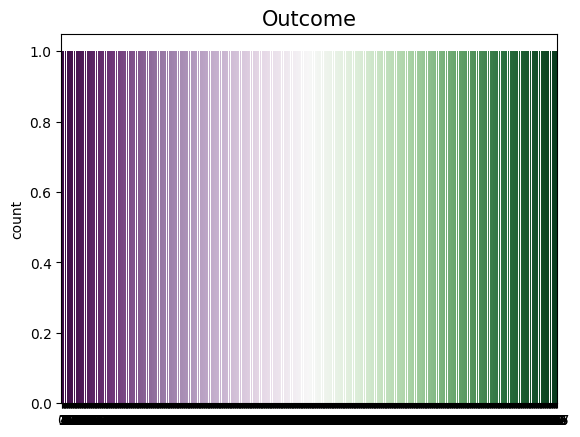

In [21]:
sns.countplot(data.Outcome, palette="PRGn")
plt.title("Outcome",fontsize=15)
plt.show()

In [22]:
# Age distribution by Outcome 0
fig = px.histogram(data, x=data[data.Outcome==0].Age,
                   marginal="box",
                   color_discrete_sequence=['lightgreen']
                  )
fig.show()

In [23]:
# Age distribution by Outcome 1
fig = px.histogram(data, x=data[data.Outcome==1].Age,
                   marginal="box",
                   color_discrete_sequence=['pink']
                  )
fig.show()

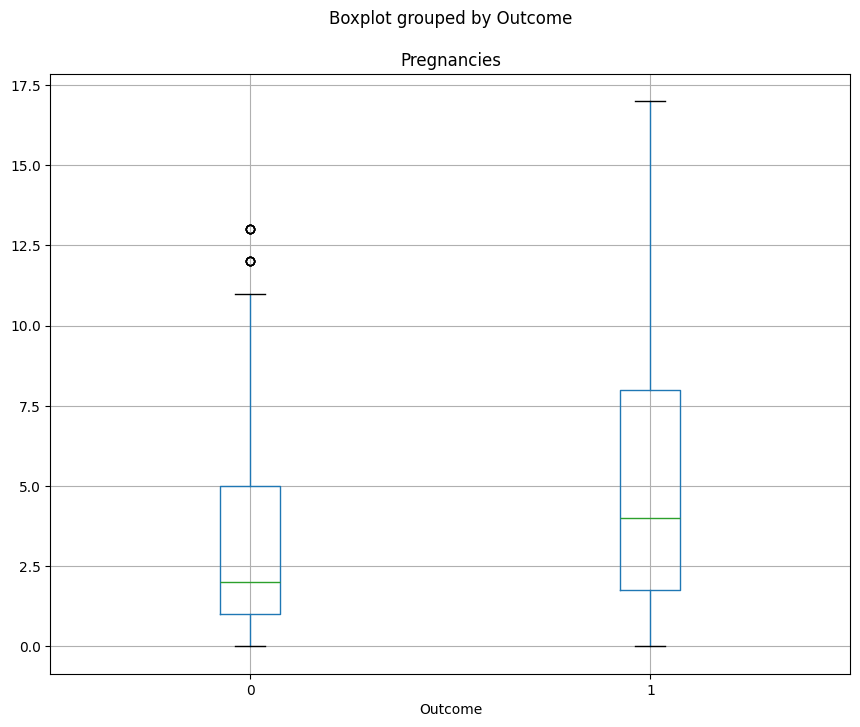

In [24]:
data.boxplot(figsize=(10,8),column='Pregnancies',by ='Outcome')
plt.show()

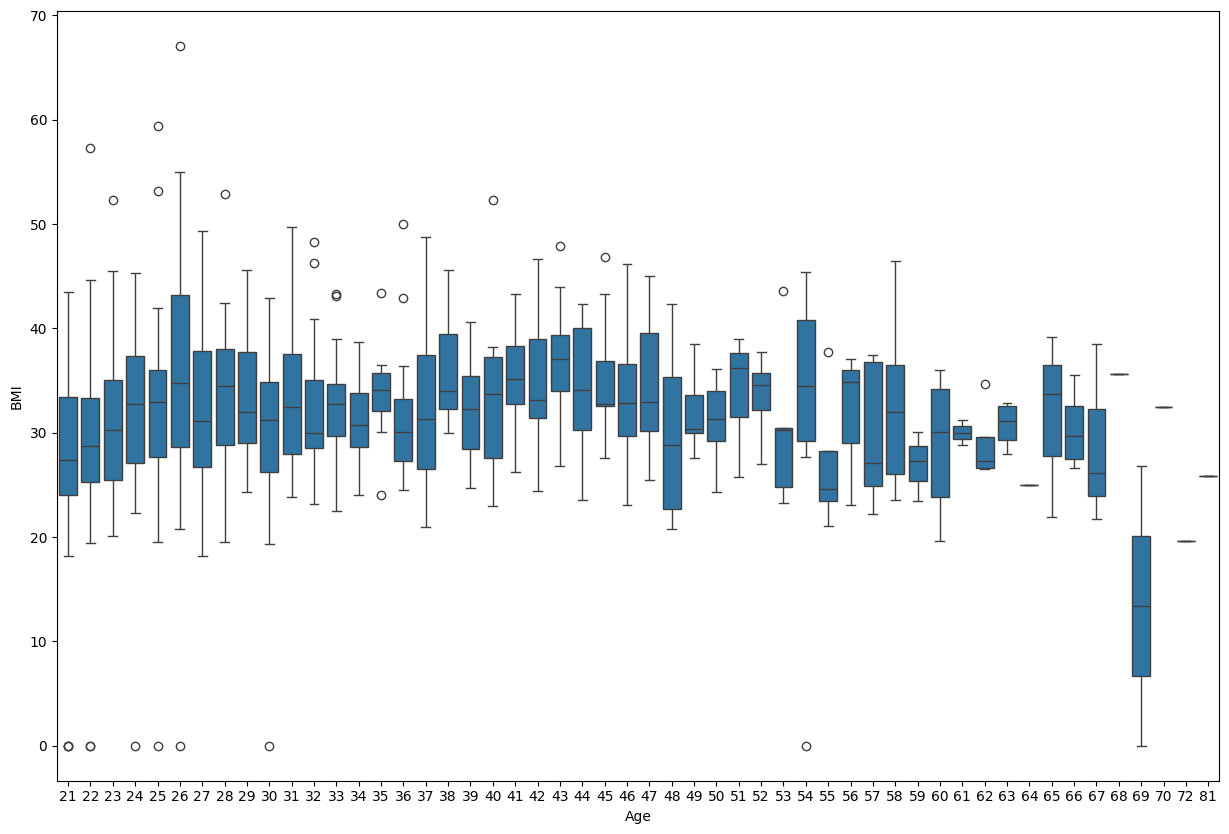

In [25]:
plt.subplots(figsize=(15,10))
sns.boxplot(x='Age', y='BMI', data=data)
plt.show()

# Logistic Regression


Logistic regression is the appropriate regression analysis to conduct when the dependent variable is dichotomous (binary). Like all regression analyzes, the logistic regression is a predictive analysis. Logistic regression is used to describe data and to explain the relationship between one dependent binary variable and one or more nominal, ordinal, interval or ratio-level independent variables.

# Diabetics Prediction Using Logistic Regression

In [26]:
x = data.drop(['Outcome'], axis = 1)
y = data.loc[:,"Outcome"].values

In [27]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.33, random_state = 123)

In [28]:
from sklearn import linear_model
logreg = linear_model.LogisticRegression(max_iter=150)

In [29]:
# Fit
logreg.fit(x_train,y_train)

LogisticRegression(max_iter=150)

In [30]:
# Predict
predicted = logreg.predict(x_test)

# Accuracy

In [31]:
print("Test accuracy: {} ".format(logreg.score(x_test, y_test)))

Test accuracy: 0.7913385826771654 


In [32]:
from sklearn.metrics import confusion_matrix
cf_matrix = confusion_matrix(y_test,predicted)
cf_matrix

array([[139,  18],
       [ 35,  62]])

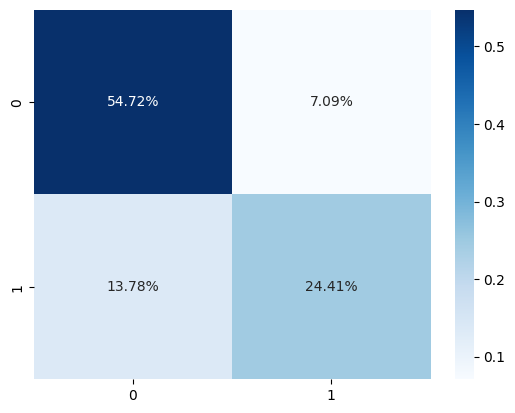

In [33]:
sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True,
            fmt='.2%', cmap='Blues')
plt.show()

In [34]:
import pickle

filename = 'trained_logistic_regression_model.pkl'

with open(filename, 'wb') as file:
    pickle.dump(logreg, file)

print(f" Model has been serialized and saved to '{filename}'.\n")


print("Step 3: Loading the model from the pickle file...")


with open(filename, 'rb') as file:
    loaded_model = pickle.load(file)

print(" Model has been deserialized and loaded successfully!\n")

print("Step 4: Using the loaded model to make predictions...")

predictions = loaded_model.predict(x_test)

print("\nSample predictions from the loaded model:")
print(predictions[:10]) # Displaying the first 10 predictions

accuracy = loaded_model.score(x_test, y_test)
print(f"\nAccuracy of the loaded model on the test set: {accuracy:.2%}")



 Model has been serialized and saved to 'trained_logistic_regression_model.pkl'.

Step 3: Loading the model from the pickle file...
 Model has been deserialized and loaded successfully!

Step 4: Using the loaded model to make predictions...

Sample predictions from the loaded model:
[1 0 1 0 0 1 1 1 1 0]

Accuracy of the loaded model on the test set: 79.13%
